This notebook is used to visualize the Danish transmission network and to identify and present the most critical nodes based on model results.

The cleaned network data (nodes and edges) is first loaded from a preprocessed Excel file. To improve readability of the geographic visualization, a small random displacement (jitter) is applied to nodes that share identical coordinates. This ensures overlapping substations can be distinguished without altering the underlying network structure.

The network is then visualized using an interactive map (Folium), where nodes and edges are plotted based on their geographic location. Nodes represent substations and are displayed either as circular markers or star icons for power plants. Edges represent transmission connections and are drawn between nodes, with dashed or solid lines indicating different transmission types. Interactive popups provide additional information such as voltage level, supply, demand, and source.

To analyze system vulnerability, model results (in this case GNN predictions) are loaded and aggregated by node. Criticality is defined as the maximum unmet demand caused by the removal of a node. This metric is normalized to allow comparison across nodes, and a score is computed to rank their relative importance.

The top-ranked nodes are then highlighted on the map. The most critical node is emphasized using a larger, darker marker, while the remaining top nodes are shown in red. Edges connected to these nodes are also highlighted, allowing identification of the most important transmission corridors.

Finally, a horizontal bar chart is generated to visualize the top critical nodes ranked by unmet demand. The layout is adjusted to ensure consistent spacing for long labels, and values are displayed directly on the bars for clarity.

In [476]:
import pandas as pd
import folium
from folium.plugins import BeautifyIcon
import webbrowser
import os
import numpy as np
from folium import FeatureGroup, LayerControl
import matplotlib.pyplot as plt


In [477]:
nodes_final = pd.read_excel("danish_grid_graph_ready.xlsx", sheet_name="nodes")
edges_final = pd.read_excel("danish_grid_graph_ready.xlsx", sheet_name="edges")

### Nodes that have the same lon and lat will be move alightly appart so that were able to see the connections between them.

In [478]:
def jitter_coordinates(df, lat_col="lat", lon_col="lon", strength=0.001):
    df = df.copy()

    dup_mask = df.duplicated(subset=[lat_col, lon_col], keep=False)

    # Gaussian noise (natural spread)
    df.loc[dup_mask, "lat_jitter"] = (
        df.loc[dup_mask, lat_col] + np.random.normal(0, strength, size=dup_mask.sum())
    )
    df.loc[dup_mask, "lon_jitter"] = (
        df.loc[dup_mask, lon_col] + np.random.normal(0, strength, size=dup_mask.sum())
    )

    # keep original for others
    df.loc[~dup_mask, "lat_jitter"] = df.loc[~dup_mask, lat_col]
    df.loc[~dup_mask, "lon_jitter"] = df.loc[~dup_mask, lon_col]

    return df

In [479]:
nodes_plot = jitter_coordinates(nodes_final, strength=0.01)
m = folium.Map(location=[56.2, 10.0], zoom_start=7, tiles="CartoDB Positron")

### Function to get specific colours for specific nodes

In [480]:
def get_node_style(row):
    name = str(row["name"]).lower()
    voltage = row["voltage_kv"]

    if "hvdc" in name:
        return "grey", "circle"
    if "windoff" in name or "havmølle" in name:
        return "grey", "circle"
    if "værket" in name:
        return "grey", "star"

    if pd.notna(voltage):
        if voltage >= 300:
            return "grey", "circle"
        elif voltage >= 200:
            return "grey", "circle"

    return "grey", "circle"

### Adding layers for intaractions on the map

In [481]:

stars_layer = FeatureGroup(name="Power plants (stars)")
nodes_layer = FeatureGroup(name="Substations")
edges_layer = FeatureGroup(name="Transmission lines")


for _, row in nodes_plot.iterrows():
    if pd.notna(row["lat_jitter"]) and pd.notna(row["lon_jitter"]):

        color, shape = get_node_style(row)

        popup_text = f"""
        <b>{row['name']}</b><br>
        Voltage: {row['voltage_kv']} kV<br>
        Supply: {row['supply']:.1f} MW<br>
        Demand: {row['demand']:.1f} MW<br>
        Source: {row['source']}
        """

        if shape == "star":
            folium.Marker(
                location=[row["lat_jitter"], row["lon_jitter"]],
                icon=folium.Icon(
                    icon="bolt",
                    prefix="fa",     # Font Awesome
                    color="black"
                ),
                popup=folium.Popup(popup_text, max_width=300)
            ).add_to(stars_layer)
        else:
            folium.CircleMarker(
                location=[row["lat_jitter"], row["lon_jitter"]],
                radius=4,
                color=color,
                fill=True,
                fill_opacity=0.8,
                popup=folium.Popup(popup_text, max_width=300)
            ).add_to(nodes_layer)


### Function to get specific colours for specific edges

In [482]:
def get_edge_style(row):
    voltage = row.get("voltage_kv", None)
    line_type = str(row.get("line_type", "")).lower()
    edge_type = row.get("edge_type", "")

    if edge_type == "hvdc":
        return "grey", "5,5"

    is_cable = "cable" in line_type

    if pd.notna(voltage):
        if voltage >= 300:
            return ("grey", "5,5") if is_cable else ("grey", None)
        elif voltage >= 200:
            return ("grey", "5,5") if is_cable else ("grey", None)
        else:
            return ("grey", "5,5") if is_cable else ("grey", None)

    return "gray", None


for _, row in edges_final.iterrows():
    n1 = nodes_plot[nodes_plot["bus_index"] == row["node1"]]
    n2 = nodes_plot[nodes_plot["bus_index"] == row["node2"]]

    if len(n1) > 0 and len(n2) > 0:
        latlon1 = n1.iloc[0][["lat_jitter", "lon_jitter"]]
        latlon2 = n2.iloc[0][["lat_jitter", "lon_jitter"]]

        if pd.notna(latlon1["lat_jitter"]) and pd.notna(latlon2["lat_jitter"]):

            color, dash = get_edge_style(row)

            folium.PolyLine(
                locations=[
                    [latlon1["lat_jitter"], latlon1["lon_jitter"]],
                    [latlon2["lat_jitter"], latlon2["lon_jitter"]]
                ],
                color=color,
                weight=2,
                opacity=0.7,
                dash_array=dash
            ).add_to(edges_layer)

stars_layer.add_to(m)
nodes_layer.add_to(m)
edges_layer.add_to(m)


### saving the map and redering in html

In [483]:
m.save("danish_grid_map.html")
webbrowser.open("file://" + os.path.realpath("danish_grid_map.html"))

True

# Interpreting the results 


### Load + aggregate by node

In [484]:
results = pd.read_excel("gnn_predictions.xlsx")

top = (
    results
    .groupby("name")
    .agg({
        "total_unmet_demand_MW": "max",
    })
    .reset_index()
)

### Normalization

In [485]:
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

top["score"] = normalize(top["total_unmet_demand_MW"])

# Top N
top = top.sort_values("score", ascending=False).head(10)

### Pulling out the top nodes

In [486]:
top5 = top.sort_values("score", ascending=False).head(10)

top1_node = top5.iloc[0]["name"].strip().lower()

print("Top 5 critical nodes:")
print(top5[[
    "name",
    "total_unmet_demand_MW",
    "score"
]])

Top 5 critical nodes:
                            name  total_unmet_demand_MW     score
112        400 KV STATION ENDRUP                 546.95  1.000000
571           z_EDR_400_XED_EE1D                 545.68  0.997800
527                     XED_EE1D                 545.50  0.997488
231             EDR_400_XED_EE1D                 536.60  0.982068
199             BJS_400_XBW_BJ1K                 351.66  0.661654
212             BWT_400_XBW_BJ1K                 348.96  0.656976
111    400 KV STATION BJÆVERSKOV                 348.80  0.656699
524                     XBW_BJ1K                 348.79  0.656682
38   150 KV STATION ENSTEDVÆRKET                  66.78  0.168090
474        SHE_150_UWN_eq_ElmLne                  66.64  0.167848


In [487]:
# Normalize names 
top5_nodes = top5["name"].str.strip().str.lower().tolist()

print("Top 5 critical nodes:")
print(top5[["name", "total_unmet_demand_MW"]])

Top 5 critical nodes:
                            name  total_unmet_demand_MW
112        400 KV STATION ENDRUP                 546.95
571           z_EDR_400_XED_EE1D                 545.68
527                     XED_EE1D                 545.50
231             EDR_400_XED_EE1D                 536.60
199             BJS_400_XBW_BJ1K                 351.66
212             BWT_400_XBW_BJ1K                 348.96
111    400 KV STATION BJÆVERSKOV                 348.80
524                     XBW_BJ1K                 348.79
38   150 KV STATION ENSTEDVÆRKET                  66.78
474        SHE_150_UWN_eq_ElmLne                  66.64


### Creating ne layers of the critical points for the graph

In [488]:
top5_nodes_layer = FeatureGroup(name="Top 5 critical nodes")
top5_edges_layer = FeatureGroup(name="Top 5 affected lines")

### Adding The nodes

In [489]:
for _, row in nodes_plot.iterrows():
    if pd.notna(row["lat_jitter"]) and pd.notna(row["lon_jitter"]):

        is_top5 = row["name"].strip().lower() in top5_nodes

        if is_top5:
            name_key = row["name"].strip().lower()
            if name_key == top1_node:
                # 🔥 MOST CRITICAL NODE
                folium.CircleMarker(
                    location=[row["lat_jitter"], row["lon_jitter"]],
                    radius=12,
                    color="darkred",
                    fill=True,
                    fill_color="darkred",
                    fill_opacity=1.0,
                    popup=folium.Popup(
                        f"<b>⚠ MOST CRITICAL NODE</b><br>{row['name']}",
                        max_width=300
                    )
                ).add_to(top5_nodes_layer)

            else:
                # normal top nodes
                folium.CircleMarker(
                    location=[row["lat_jitter"], row["lon_jitter"]],
                    radius=8,
                    color="red",
                    fill=True,
                    fill_opacity=1.0,
                    popup=folium.Popup(
                        f"<b>CRITICAL NODE</b><br>{row['name']}",
                        max_width=300
                    )
                ).add_to(top5_nodes_layer)


# Adding the edges connected 
for _, row in edges_final.iterrows():
    n1 = nodes_plot[nodes_plot["bus_index"] == row["node1"]]
    n2 = nodes_plot[nodes_plot["bus_index"] == row["node2"]]

    if len(n1) > 0 and len(n2) > 0:
        latlon1 = n1.iloc[0][["lat_jitter", "lon_jitter"]]
        latlon2 = n2.iloc[0][["lat_jitter", "lon_jitter"]]

        if pd.notna(latlon1["lat_jitter"]) and pd.notna(latlon2["lat_jitter"]):

            is_top5_edge = (
                n1.iloc[0]["name"].strip().lower() in top5_nodes
                or n2.iloc[0]["name"].strip().lower() in top5_nodes
            )

            name1 = n1.iloc[0]["name"].strip().lower()
            name2 = n2.iloc[0]["name"].strip().lower()

            # 🔥 Check if this edge touches the MOST critical node
            if name1 == top1_node or name2 == top1_node:
                color = "darkred"
                weight = 6

            # Otherwise: normal critical edge
            elif is_top5_edge:
                color = "red"
                weight = 4

            # Skip non-critical edges
            else:
                continue

            folium.PolyLine(
                locations=[
                    [latlon1["lat_jitter"], latlon1["lon_jitter"]],
                    [latlon2["lat_jitter"], latlon2["lon_jitter"]]
                ],
                color=color,
                weight=weight,
                opacity=1.0
            ).add_to(top5_edges_layer)

### Adding to existing map

In [490]:
stars_layer.add_to(m)
nodes_layer.add_to(m)
edges_layer.add_to(m)

top5_nodes_layer.add_to(m)
top5_edges_layer.add_to(m)

LayerControl().add_to(m)

In [491]:
m.save("danish_grid_map_results.html")
webbrowser.open("file://" + os.path.realpath("danish_grid_map_results.html"))

True

In [492]:
top5[["name"]]


,name
112,400 KV STATION ENDRUP
571,z_EDR_400_XED_EE1D
527,XED_EE1D
231,EDR_400_XED_EE1D
199,BJS_400_XBW_BJ1K
212,BWT_400_XBW_BJ1K
111,400 KV STATION BJÆVERSKOV
524,XBW_BJ1K
38,150 KV STATION ENSTEDVÆRKET
474,SHE_150_UWN_eq_ElmLne


In [493]:
nodes_final[nodes_final["name"].isin(top5["name"])][["name", "lat", "lon"]]

,name,lat,lon
22,XBW_BJ1K,54.161015,12.077979
25,XED_EE1D,53.716319,6.901904
80,400 KV STATION BJÆVERSKOV,55.457600,12.036500
305,400 KV STATION ENDRUP,55.607000,8.398000
469,150 KV STATION ENSTEDVÆRKET,54.846000,9.467000
470,150 KV STATION ENSTEDVÆRKET,54.846000,9.467000
471,150 KV STATION ENSTEDVÆRKET,54.846000,9.467000
472,150 KV STATION ENSTEDVÆRKET,54.846000,9.467000


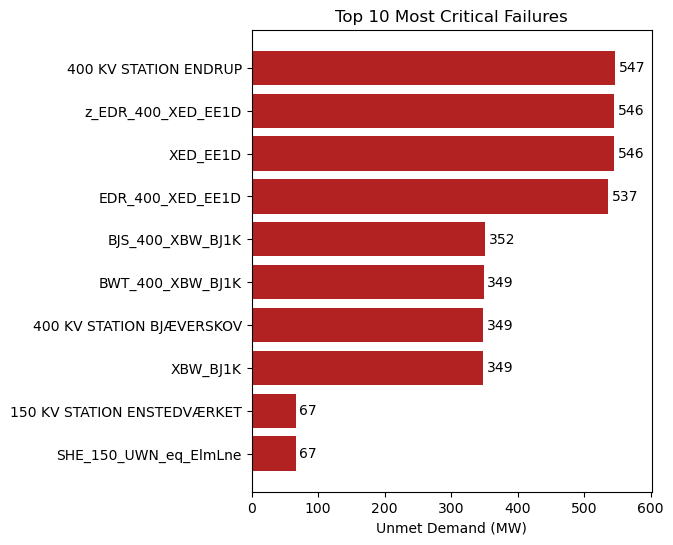

In [ ]:
# Top N
N = 10
topN = top5.sort_values("score", ascending=False).head(N)

topN = topN.sort_values("total_unmet_demand_MW", ascending=True)

plt.figure(figsize=(8, 6))

plt.subplots_adjust(left=0.4)

bars = plt.barh(
    topN["name"],
    topN["total_unmet_demand_MW"],
    color="firebrick"
)

# Lock axis
plt.xlim(0, top5["total_unmet_demand_MW"].max() * 1.1)

plt.xlabel("Unmet Demand (MW)")
plt.title(f"Top {N} Most Critical Failures")

# Add values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f"{width:.0f}", va='center')

plt.show()